In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('../../data/processed/telecom_encoding.csv')
df

,id,gender,age,year,school,income,job,phone_usage_per_m,mobile_bundle,telecom_change_yn,...,jeonbuk,jeonnam,gyeongbuk,gyeongnam,jeju,sejong,skt,kt,lgu,mvno
0,10002,0,45,2017,4,0,0,29,0,0,...,0,0,0,0,0,0,1,0,0,0
1,10002,0,46,2018,4,0,0,35,1,0,...,0,0,0,0,0,0,1,0,0,0
2,10002,0,47,2019,4,0,0,58,1,0,...,0,0,0,0,0,0,1,0,0,0
3,10002,0,48,2020,4,0,0,37,1,1,...,0,0,0,0,0,0,0,1,0,0
4,10002,0,49,2021,4,0,0,32,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34366,71660003,0,24,2021,4,2,1,33,1,0,...,0,0,0,0,0,0,1,0,0,0
34367,71660003,0,25,2022,4,2,0,105,1,0,...,0,0,0,0,0,0,1,0,0,0
34368,71660003,0,26,2023,4,1,0,50,1,0,...,0,0,0,0,0,0,1,0,0,0
34369,71660003,0,27,2024,4,0,0,63,1,0,...,0,0,0,0,0,0,1,0,0,0


In [16]:
df['telecom_change_yn'].value_counts()

telecom_change_yn
0    22948
1    11423
Name: count, dtype: int64

### 범주형 데이터 수치화
- 소득 (income)

In [10]:
# 소득(income) 매핑
income_map = {
    1: 0, 2: 25, 3: 75, 4: 125, 5: 175, 6: 225, 7: 275, 8: 325, 9: 375, 10: 425, 11: 475, 12: 525, 13: 575, 14: 625, 15: 675, 16: 725, 17: 775, 18: 850
    }


df['income_val'] = df['income'].map(income_map)

# 소득 대비 통신비 부담률
df['usage_per_income'] = (df['phone_usage_per_m'] / (df['income_val'] + 1)) * 100

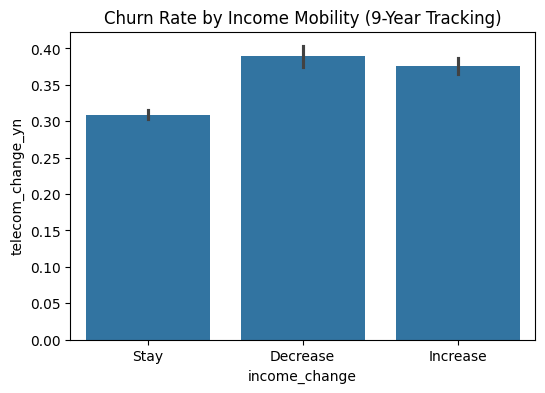

In [11]:
# 전년 대비 소득 증감 변수 생성
df = df.sort_values(['id', 'year'])
df['income_diff'] = df.groupby('id')['income_val'].diff()
df['income_change'] = df['income_diff'].apply(lambda x: 'Decrease' if x < 0 else ('Increase' if x > 0 else 'Stay'))

# 소득 변화 유형별 이탈률 시각화
plt.figure(figsize=(6, 4))
sns.barplot(data=df.dropna(subset=['income_change']), 
            x='income_change', y='telecom_change_yn')
plt.title("Churn Rate by Income Mobility (9-Year Tracking)")
plt.show()

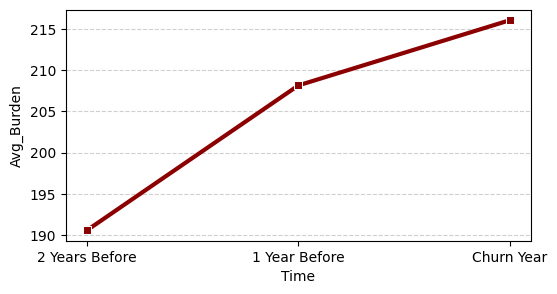

In [12]:
# 이탈 직전 해의 데이터 추출
df['prev_burden'] = df.groupby('id')['usage_per_income'].shift(1)
df['prev_2_burden'] = df.groupby('id')['usage_per_income'].shift(2)

# 이탈한 케이스의 직전 상태 확인
churn_cases = df[df['telecom_change_yn'] == 1].copy()

# 이탈한 순간들의 직전 1, 2년 전 부담률 평균
trend_data = {
    'Time': ['2 Years Before', '1 Year Before', 'Churn Year'],
    'Avg_Burden': [
        churn_cases['prev_2_burden'].mean(),
        churn_cases['prev_burden'].mean(),
        churn_cases['usage_per_income'].mean()
    ]
}
trend_df = pd.DataFrame(trend_data)

plt.figure(figsize=(6, 3))
sns.lineplot(data=trend_df, x='Time', y='Avg_Burden', marker='s', color='darkred', linewidth=3)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [14]:
df['prev_usage'] = df.groupby('id')['phone_usage_per_m'].shift(1)
df['prev_2_usage'] = df.groupby('id')['phone_usage_per_m'].shift(2)

churn_cases = df[df['telecom_change_yn'] == 1].copy()

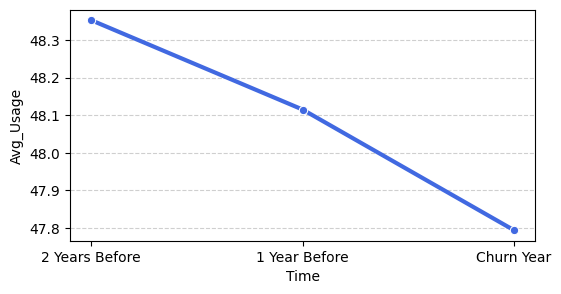

In [15]:
# 이탈한 케이스의 직전 사용 금액 상태 확인
trend_data_usage = {
    'Time': ['2 Years Before', '1 Year Before', 'Churn Year'],
    'Avg_Usage': [
        churn_cases['prev_2_usage'].mean(),
        churn_cases['prev_usage'].mean(),
        churn_cases['phone_usage_per_m'].mean()
    ]
}

# churn_cases 업데이트
churn_cases = df[df['telecom_change_yn'] == 1].copy()

trend_usage_df = pd.DataFrame({
    'Time': ['2 Years Before', '1 Year Before', 'Churn Year'],
    'Avg_Usage': [
        churn_cases['prev_2_usage'].mean(),
        churn_cases['prev_usage'].mean(),
        churn_cases['phone_usage_per_m'].mean()
    ]
})

plt.figure(figsize=(6, 3))
sns.lineplot(data=trend_usage_df, x='Time', y='Avg_Usage', marker='o', color='royalblue', linewidth=3)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()